# Wine Cultivar  with Random Forest
The dataset being used is [Wine dataset.csv](../data/Wine%20dataset.csv). These data are the results of a chemical analysis of wines grown in the same region in Italy but derived from three different cultivars. The analysis determined the quantities of 13 constituents found in each of the three types of wines. 

## Setup
Importing Python libraries and modules

In [79]:
# # This Python 3 environment comes with many helpful analytics libraries installed
# # It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# # For example, here's several helpful packages to load

# import numpy as np # linear algebra
# import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# # Input data files are available in the read-only "../input/" directory
# # For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# # You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# # You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# # Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# # Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

# import kagglehub
# # kagglehub.dataset_download('<owner>/<dataset-slug>')

In [1]:
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns
from scipy.stats import f_oneway
import numpy as np
import pandas as pd

In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

## Load Dataset

In [3]:
# wine = pd.read_csv("/kaggle/input/datasets/tawfikelmetwally/wine-dataset/Wine dataset.csv") # for kaggle
wine = pd.read_csv(r"../data\Wine dataset.csv")

## Exploratory Data Analysis (EDA)

- Check for missing values
- Check target class balance
- Examine variance and scale

### Data Quality Check

In [4]:
wine.info()

<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   class                         178 non-null    int64  
 1   Alcohol                       178 non-null    float64
 2   Malic acid                    178 non-null    float64
 3   Ash                           178 non-null    float64
 4   Alcalinity of ash             178 non-null    float64
 5   Magnesium                     178 non-null    int64  
 6   Total phenols                 178 non-null    float64
 7   Flavanoids                    178 non-null    float64
 8   Nonflavanoid phenols          178 non-null    float64
 9   Proanthocyanins               178 non-null    float64
 10  Color intensity               178 non-null    float64
 11  Hue                           178 non-null    float64
 12  OD280/OD315 of diluted wines  178 non-null    float64
 13  Proline         

### Checking for Missing Values

In [5]:
## Check basic shape & missing values
print(f"Dataset Shape: {wine.shape}")
print(f"Missing Values Count: \n{wine.isnull().sum().sum()}")

Dataset Shape: (178, 14)
Missing Values Count: 
0


### Checking for Target Class Balance

In [6]:
## Class Distribution Check
print(f"\nClass Distribution: \n{wine["class"].value_counts()}")


Class Distribution: 
class
2    71
1    59
3    48
Name: count, dtype: int64


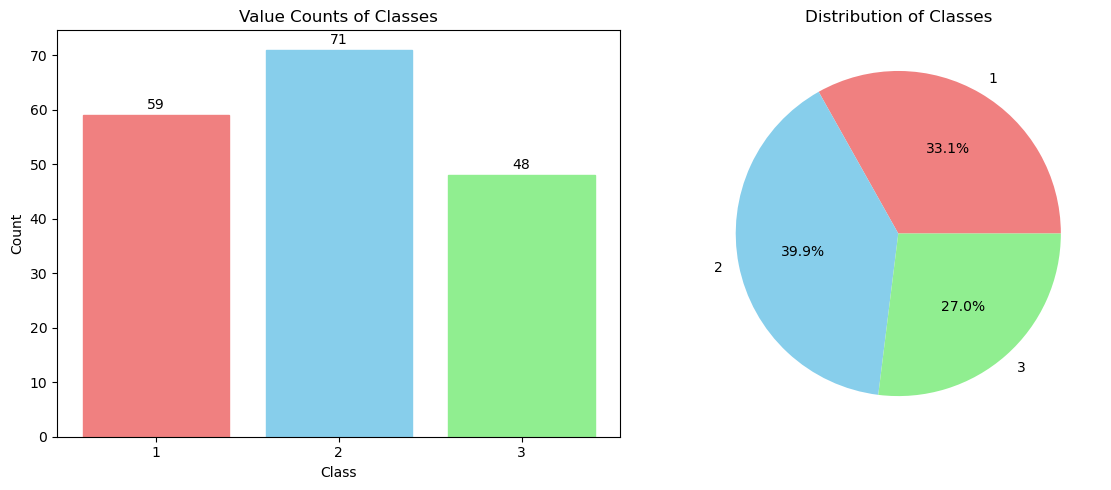

In [7]:
# Define consistent colors for each class
class_colors = {
    1: 'lightcoral',
    2: 'skyblue', 
    3: 'lightgreen'
}

# Get value counts
value_counts = wine["class"].value_counts().sort_index()

# Create subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Bar plot
bars = ax1.bar(value_counts.index, value_counts.values)
for bar, cls in zip(bars, value_counts.index):
    bar.set_color(class_colors[cls])
    # Add value label on top of each bar
    height = bar.get_height() # get the height of each bar
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.5, f"{int(height)}", ha='center', va='bottom')
ax1.set_xlabel('Class')
ax1.set_ylabel('Count')
ax1.set_title('Value Counts of Classes')
ax1.set_xticks(value_counts.index)

# Pie chart
pie_colors = [class_colors[cls] for cls in value_counts.index]
ax2.pie(value_counts.values, labels=value_counts.index, autopct='%1.1f%%', colors=pie_colors)
ax2.set_title('Distribution of Classes')

plt.tight_layout()
plt.show()

Results:
The distribution of `class` feature is relatively balance (59, 71, and 48). There're no extreme inbalance nor reweighteing needed between them.

### Examine Variance and Scale
Since the `class` is the target feature, we will exclude it to show the statistics of the first 3 features.

In [8]:
## Summary Statistics (Meaan, std, Min, Max)
print("First 3 Features Summary:")
wine.iloc[:,1:4].describe().T[['mean', 'std', 'min', 'max']] # .iloc[row, column]

First 3 Features Summary:


,mean,std,min,max
Alcohol,13.000618,0.811827,11.03,14.83
Malic acid,2.336348,1.117146,0.74,5.80
Ash,2.366517,0.274344,1.36,3.23


In [9]:
wine.iloc[:,1:].describe().T[['mean', 'std', 'min', 'max']] # all features, except `class`

,mean,std,min,max
Alcohol,13.000618,0.811827,11.03,14.83
Malic acid,2.336348,1.117146,0.74,5.80
Ash,2.366517,0.274344,1.36,3.23
Alcalinity of ash,19.494944,3.339564,10.60,30.00
Magnesium,99.741573,14.282484,70.00,162.00
Total phenols,2.295112,0.625851,0.98,3.88
Flavanoids,2.029270,0.998859,0.34,5.08
Nonflavanoid phenols,0.361854,0.124453,0.13,0.66
Proanthocyanins,1.590899,0.572359,0.41,3.58
Color intensity,5.058090,2.318286,1.28,13.00


Observations:
1. Comparing `std` to `mean`: Nothing unsually since all `std` values are **smaller** than their `mean`. Some features (`Ash`) has low variability, `mean` is 2.36 and `std` is 0.27 (barely move, 11%). While other featuers (`Flavanoids`) has high variability, `mean` is 2.02 and `std` is 0.99 (moves a lot relative to its size, 49%)
2. Comparing `min` and `max`: Some features (`alcohol`) are tight, while others (`proline` and `malic_acid` are spread out)
3. Comparing `mean` to `min` and `max`:
    - `malic_acid`: `mean`=2.34 is closer to `min`=0.74, so it's skewed toward the higher end, **right-skewed**
    - `color_intensity`: `mean`=5.05 is closer to `min`=1.28 (`max`=13, more than 2.5x higher than `mean`). It's skewed toward the **right-skewed**.
    - `magnesium`: `mean`=99.74 is closer to `min`=70 (`max`=162, 1.6x more higher than `mean`). It's skewed toward the **right-skewed**.
4. Comparing `max` or `mean`: The max varies from 0.66(Nonflavanoid phenols) to 1680(Proline). These 2 features live on completely different orders of magnitude. Distance-based algorithms (PCA, K-NN, or SVMs) will be completely dominated by `Proline` simply because its values are so large. *Standardization* (such as `StandardScaler`) is **non-negotiable** if we're going to use `Proline` with other features.

### Feature vs. Target

#### Before Standardized

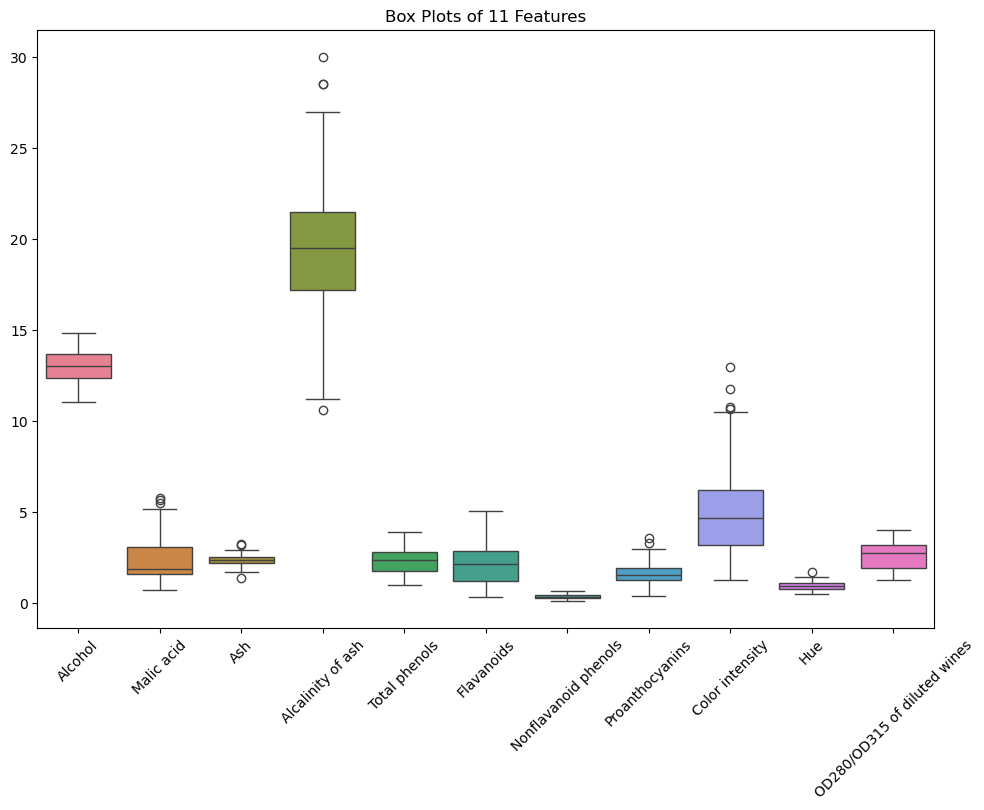

In [10]:
plt.figure(figsize=(10,8))
sns.boxplot(data=wine.drop(columns=['class', 'Proline ', 'Magnesium']))
plt.xticks(rotation=45)
plt.tight_layout()
plt.title("Box Plots of 11 Features")
plt.show()

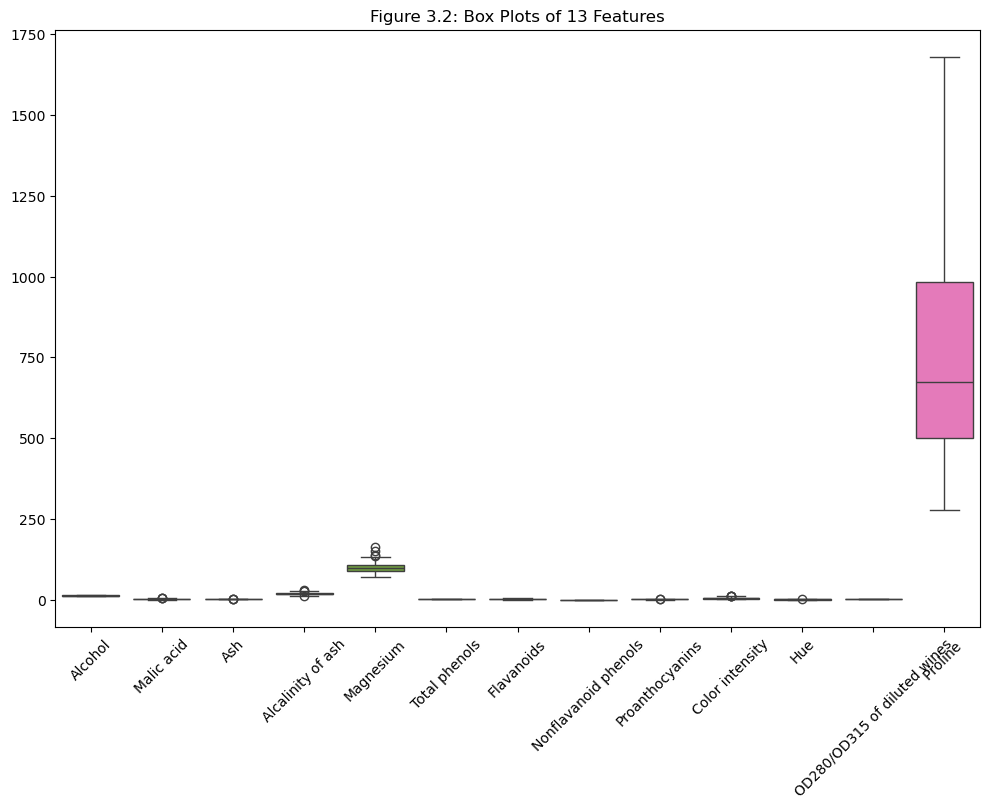

In [11]:
# all features in one plot
plt.figure(figsize=(10,8))
sns.boxplot(data=wine.iloc[:, 1:])
plt.xticks(rotation=45)
plt.tight_layout()
plt.title("Figure 3.2: Box Plots of 13 Features")
plt.show()

# Alternative: melt the data for better seaborn integration
# wine_melted = wine.iloc[:, 1:].melt(var_name='Feature', value_name='Value')
# sns.boxplot(data=wine_melted, x='Feature', y='Value')
# plt.xticks(rotation=45)
# plt.tight_layout()
# plt.show()

From **Figure 3.2**, many features are in different range, especially `Proline`. It's another evidence to standardized the features.

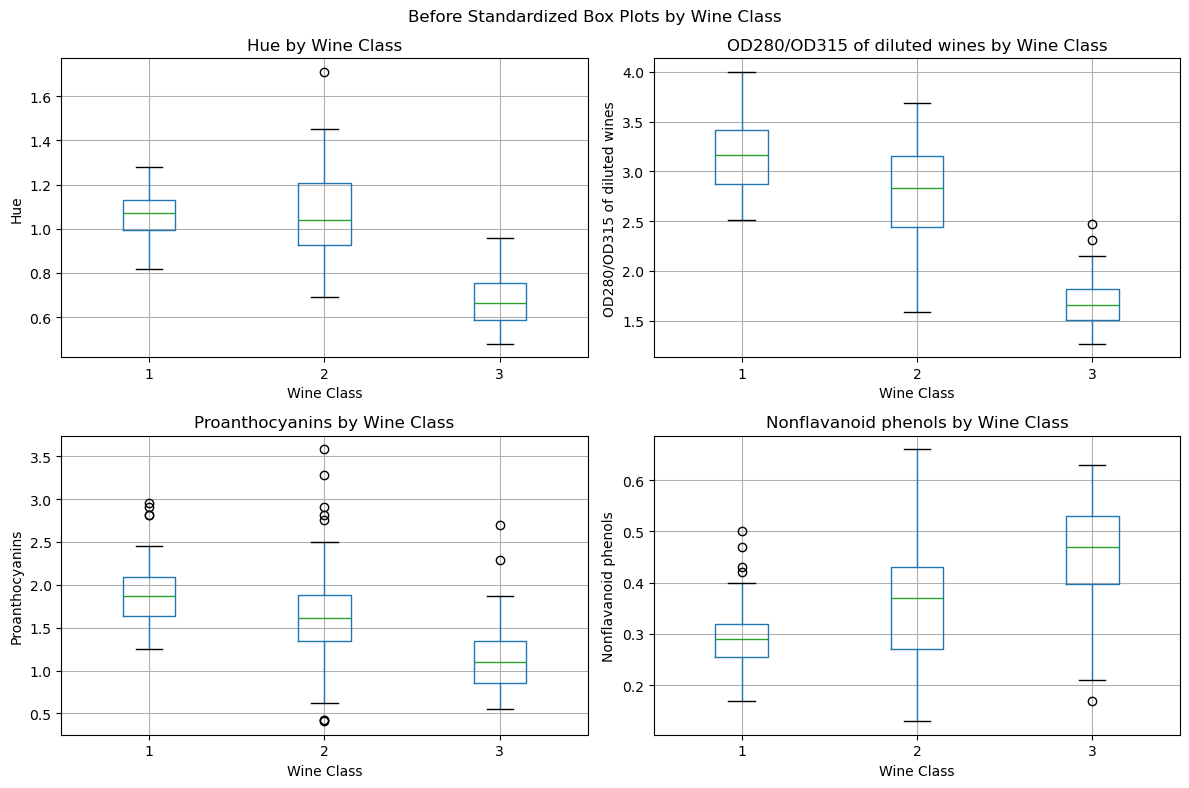

In [12]:
features_to_plot = ['Hue', 'OD280/OD315 of diluted wines', 'Proanthocyanins', 'Nonflavanoid phenols']
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for idx, feature in enumerate(features_to_plot):
    # Box plot for each class
    wine.boxplot(column=feature, by='class', ax=axes[idx])
    axes[idx].set_title(f'{feature} by Wine Class')
    axes[idx].set_xlabel('Wine Class')
    axes[idx].set_ylabel(feature)

plt.suptitle('Before Standardized Box Plots by Wine Class')  # Remove default title
plt.tight_layout()
plt.show()

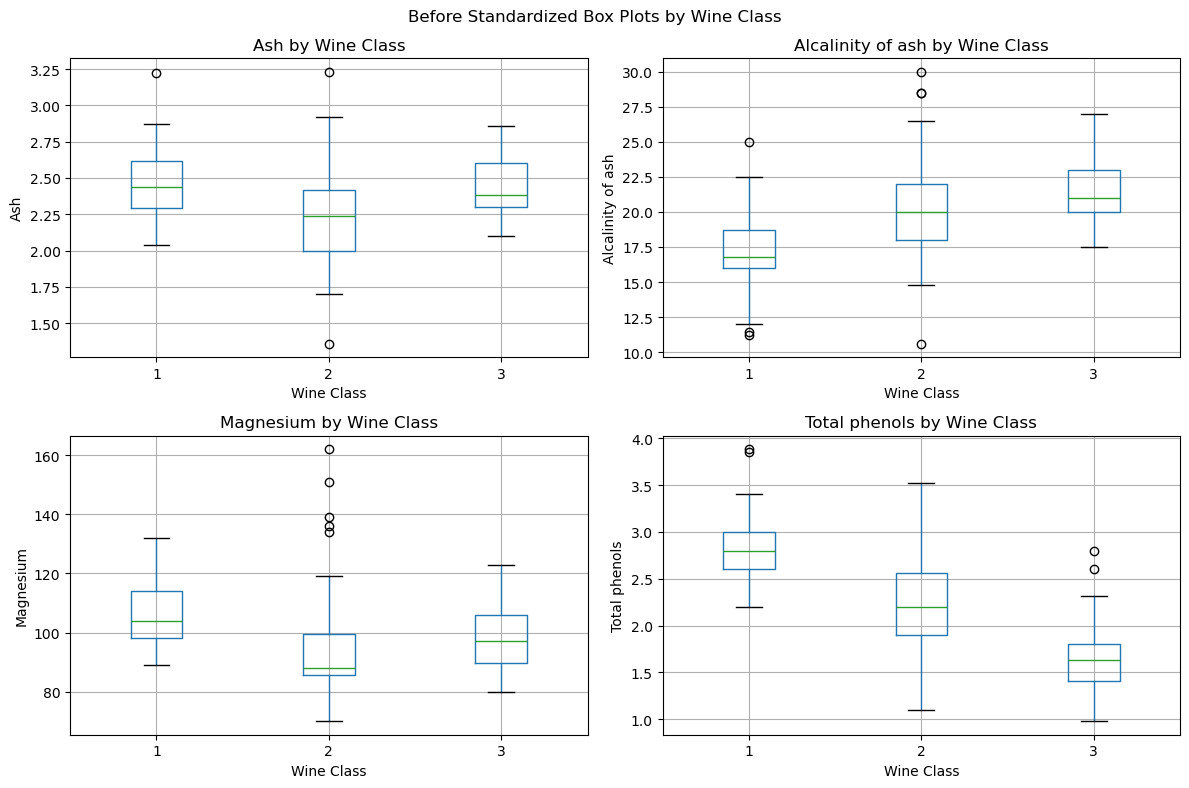

In [13]:
features_to_plot = ['Ash', 'Alcalinity of ash', 'Magnesium', 'Total phenols']
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for idx, feature in enumerate(features_to_plot):
    # Box plot for each class
    wine.boxplot(column=feature, by='class', ax=axes[idx])
    axes[idx].set_title(f'{feature} by Wine Class')
    axes[idx].set_xlabel('Wine Class')
    axes[idx].set_ylabel(feature)

plt.suptitle('Before Standardized Box Plots by Wine Class')  # Remove default title
plt.tight_layout()
plt.show()

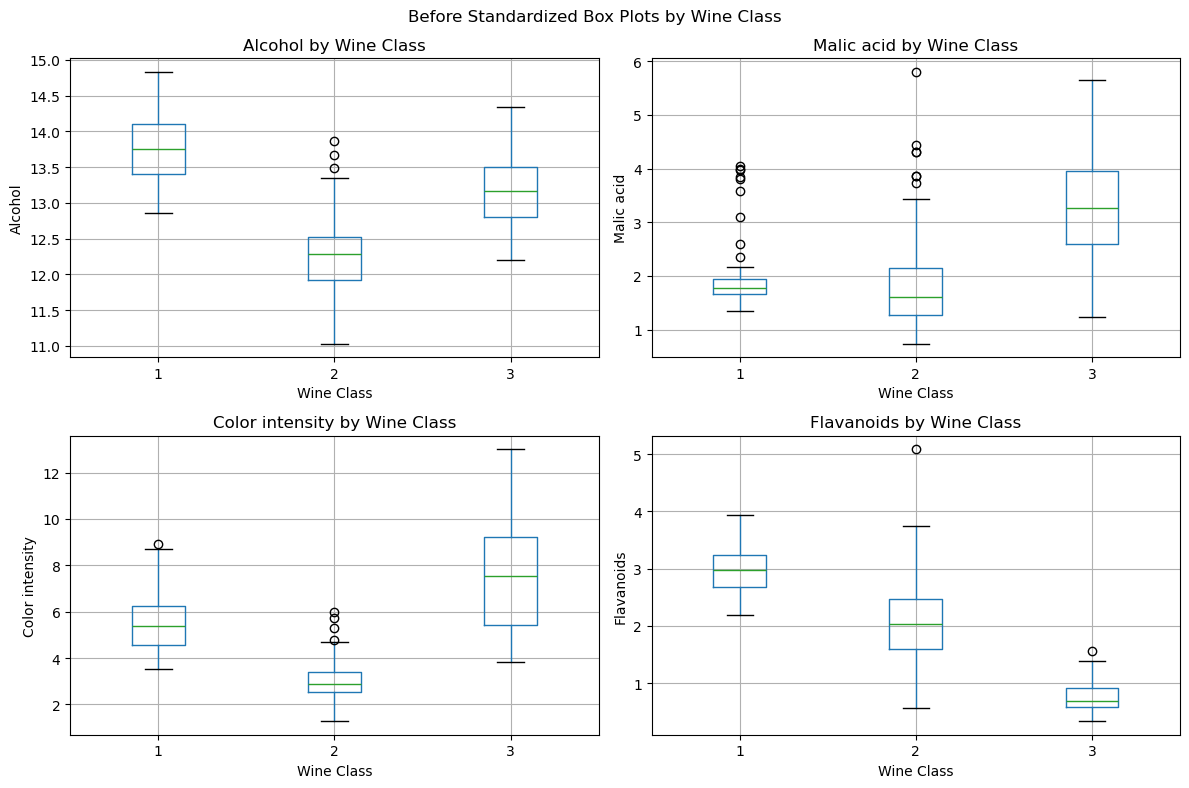

In [14]:
# Pick a few features to visualize (don't plot all 13 at once)
features_to_plot = ['Alcohol', 'Malic acid', 'Color intensity', 'Flavanoids']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for idx, feature in enumerate(features_to_plot):
    # Box plot for each class
    wine.boxplot(column=feature, by='class', ax=axes[idx])
    axes[idx].set_title(f'{feature} by Wine Class')
    axes[idx].set_xlabel('Wine Class')
    axes[idx].set_ylabel(feature)

plt.suptitle('Before Standardized Box Plots by Wine Class')  # Remove default title
plt.tight_layout()
plt.show()

From the box plots by class of each features, there's no indication of bad predictors. Because of the medians of each box shift across their classes.

#### Standardized all features

In [15]:
# Standardize all features
scaler = StandardScaler()
wine_scaled = pd.DataFrame(
    scaler.fit_transform(wine.iloc[:, 1:14]),
    columns=wine.columns[1:14]
)

In [16]:
wine_scaled.insert(0, 'class', wine['class']) # add class feature
wine_scaled.info()

<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   class                         178 non-null    int64  
 1   Alcohol                       178 non-null    float64
 2   Malic acid                    178 non-null    float64
 3   Ash                           178 non-null    float64
 4   Alcalinity of ash             178 non-null    float64
 5   Magnesium                     178 non-null    float64
 6   Total phenols                 178 non-null    float64
 7   Flavanoids                    178 non-null    float64
 8   Nonflavanoid phenols          178 non-null    float64
 9   Proanthocyanins               178 non-null    float64
 10  Color intensity               178 non-null    float64
 11  Hue                           178 non-null    float64
 12  OD280/OD315 of diluted wines  178 non-null    float64
 13  Proline         

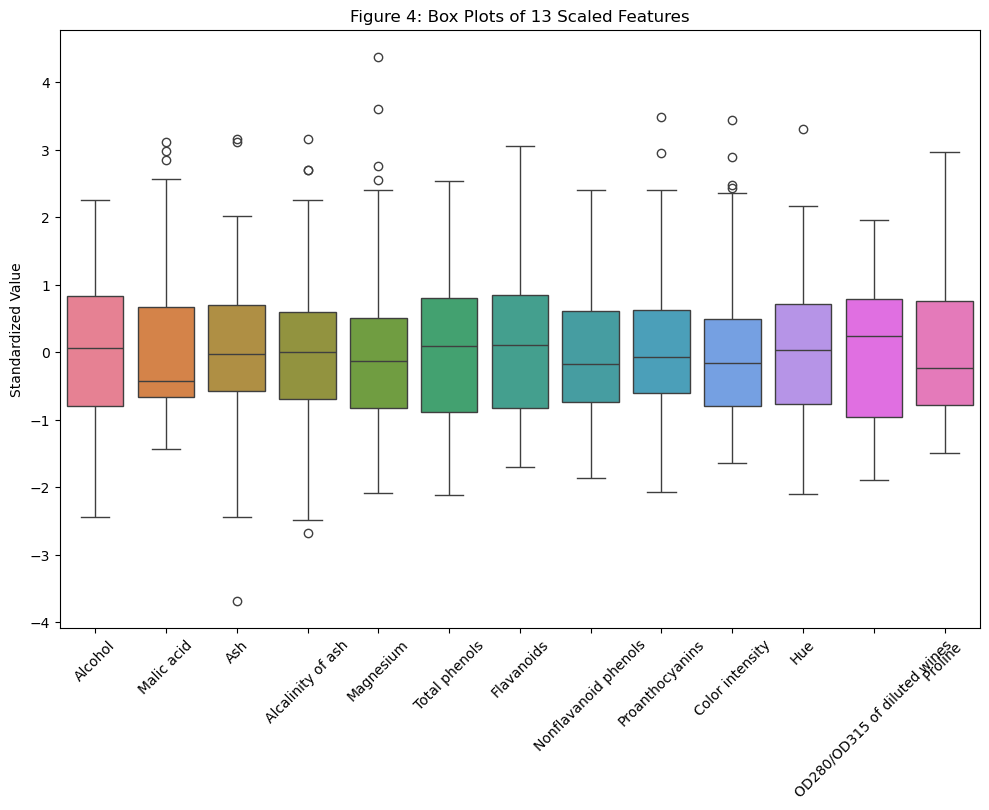

In [17]:
plt.figure(figsize=(10,8))
sns.boxplot(data=wine_scaled.iloc[:, 1:])
plt.xticks(rotation=45)
plt.ylabel('Standardized Value')
plt.tight_layout()
plt.title("Figure 4: Box Plots of 13 Scaled Features")
plt.show()

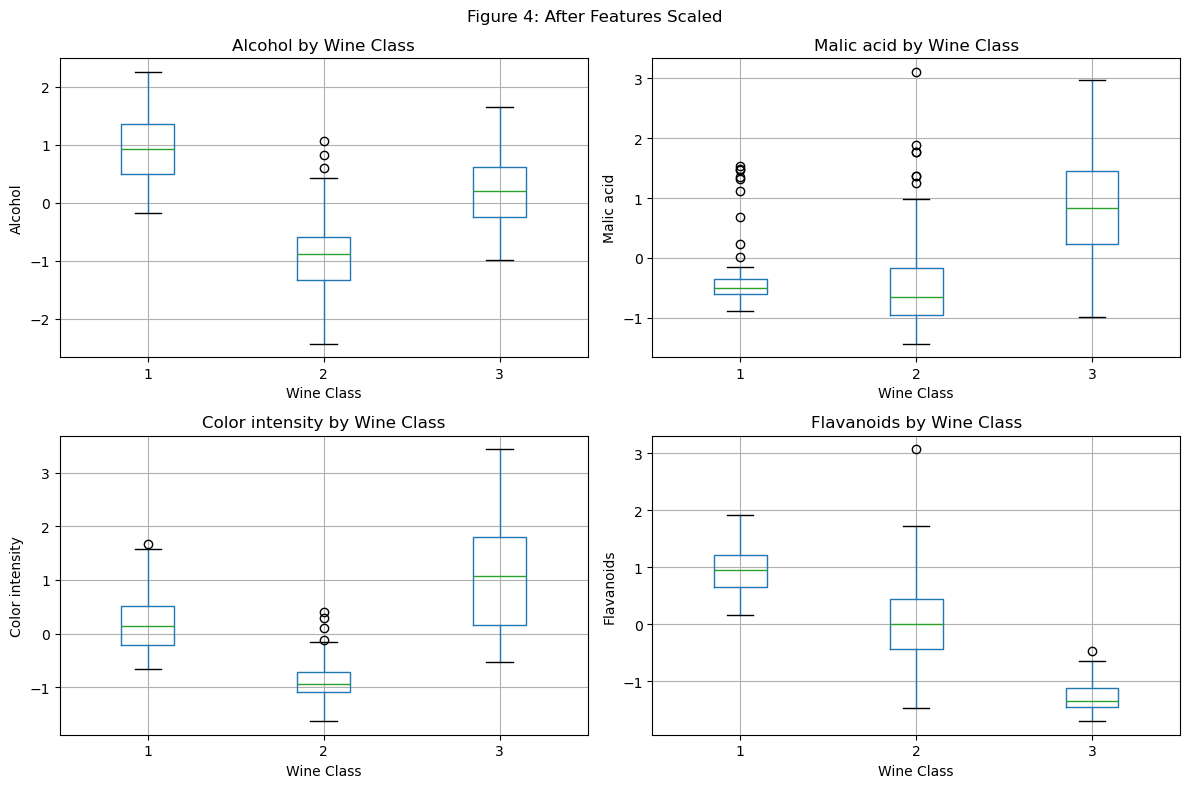

In [18]:
# Pick a few features to visualize (don't plot all 13 at once)
features_to_plot = ['Alcohol', 'Malic acid', 'Color intensity', 'Flavanoids']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for idx, feature in enumerate(features_to_plot):
    # Box plot for each class
    wine_scaled.boxplot(column=feature, by='class', ax=axes[idx])
    axes[idx].set_title(f'{feature} by Wine Class')
    axes[idx].set_xlabel('Wine Class')
    axes[idx].set_ylabel(feature)

plt.suptitle('Figure 4: After Features Scaled')  # Remove default title
plt.tight_layout()
plt.show()

In [19]:
print(wine_scaled.iloc[:, 1:].describe().T[['50%']])

                                   50%
Alcohol                       0.061000
Malic acid                   -0.423112
Ash                          -0.023821
Alcalinity of ash             0.001518
Magnesium                    -0.122282
Total phenols                 0.095960
Flavanoids                    0.106150
Nonflavanoid phenols         -0.176095
Proanthocyanins              -0.062898
Color intensity              -0.159225
Hue                           0.033127
OD280/OD315 of diluted wines  0.237735
Proline                      -0.233720


In [20]:
wine_scaled.rename(columns={"Proline ": 'Proline'}, inplace=True)

## Univariate Analysis
1. [Statistical Test (ANOVA test)](#analysis-of-variance-avona-test): which features are predictive
2. [Cumulative Analysis](#): how many features are needed
3. [Correlation Matrix](#correlation-matrix): check if selected features are redundant

### Analysis of Variance (ANOVA Test)
- **Good predictors**: High F-statistic p-value<0.05 (statistically significant).
- **Bad predictors**: Low F-statistic, p-value>0.05 (not significant)

In [21]:
# For each feature, measure "separation" using ANOVA
features = wine_scaled.columns  # Use scaled data
anova_results = []

for feature in features:
    class1 = wine_scaled[wine['class'] == 1][feature]
    class2 = wine_scaled[wine['class'] == 2][feature]
    class3 = wine_scaled[wine['class'] == 3][feature]
    
    f_stat, p_value = f_oneway(class1, class2, class3)
    anova_results.append({
        'Feature': feature,
        'F-statistic': f_stat,
        'Strong Predictors (F-statistic > 50)': 'Yes' if f_stat > 50 else 'No',
        'P-value': p_value,
        'Significant': 'Yes' if p_value < 0.05 else 'No',
    })

anova_df = pd.DataFrame(anova_results).sort_values('F-statistic', ascending=False)
anova_df

c:\Users\Thao\miniconda3\envs\DataScienceStudy\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: ConstantInputWarning: Each of the input arrays is constant; the F statistic is not defined or infinite
  res = hypotest_fun_out(*samples, **kwds)


,Feature,F-statistic,Strong Predictors (F-statistic > 50),P-value,Significant
0,class,inf,Yes,0.000000e+00,Yes
7,Flavanoids,233.925873,Yes,3.598586e-50,Yes
13,Proline,207.920374,Yes,5.783168e-47,Yes
12,OD280/OD315 of diluted wines,189.972321,Yes,1.393105e-44,Yes
1,Alcohol,135.077624,Yes,3.319504e-36,Yes
10,Color intensity,120.664018,Yes,1.162008e-33,Yes
11,Hue,101.316795,Yes,5.917662e-30,Yes
6,Total phenols,93.733010,Yes,2.137670e-28,Yes
2,Malic acid,36.943425,No,4.127229e-14,Yes
4,Alcalinity of ash,35.771637,No,9.444473e-14,Yes


### Cumulative Analysis

In [22]:
# What % of predictive power comes from top N features?
sorted_features = anova_df.iloc[1:].sort_values('F-statistic', ascending=False)
cumsum = sorted_features['F-statistic'].cumsum()
cumsum_pct = round((cumsum / cumsum.max()) * 100, 2)

print(f'Cumulative Variance: \n{cumsum_pct}')
# Top 1: ~28%
# Top 2: ~50%
# Top 3: ~68%
# Top 4: ~80%
# Top 5: ~88%

Cumulative Variance: 
7      18.88
13     35.66
12     51.00
1      61.90
10     71.64
11     79.82
6      87.38
2      90.37
4      93.25
9      95.70
8      97.92
3      99.00
5     100.00
Name: F-statistic, dtype: float64


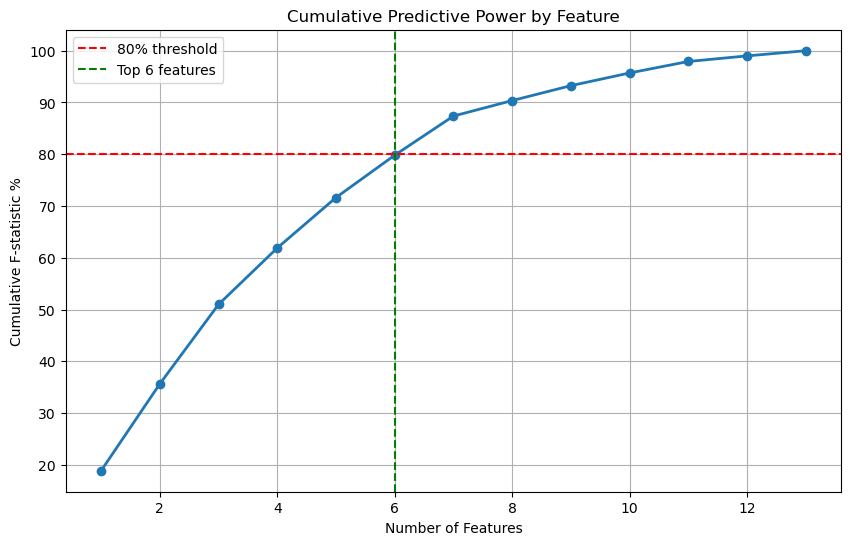

In [23]:
# cumsum_pct = (cumsum / cumsum.max()) * 100
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumsum_pct)+1), cumsum_pct, marker='o', linewidth=2)
plt.axhline(y=80, color='r', linestyle='--', label='80% threshold')
plt.axvline(x=6, color='g', linestyle='--', label='Top 6 features')
plt.xlabel('Number of Features')
plt.ylabel('Cumulative F-statistic %')
plt.title('Cumulative Predictive Power by Feature')
plt.legend()
plt.grid()
plt.show()

Based on the **ANOVA** results, the top 4 featurers with the highest **F-score**:
- `Flavanoids`
- `Proline`
- `OD280/OD315 of diluted wines`
- `Alcohol`

These 4 features are the best predictors of origin, these features capture 62% of the total discriminative power. Adding the 5th feature (`Color intensity`) brings it to 71.6% power with minimal complexity cost.

In [24]:
from sklearn.decomposition import PCA

pca = PCA().fit(wine_scaled)
print(pca.explained_variance_ratio_.cumsum())

[0.38203095 0.56567328 0.67202328 0.73992345 0.8037677  0.85239334
 0.89305614 0.91874902 0.9402075  0.95917177 0.97578004 0.98819302
 0.99681179 1.        ]


### Correlation Matrix
After we've found the strongest featurers, we will drop features that duplicate existing singal using a **correlation matrix**.

In [25]:
# anova_df.iloc[1:5]["Feature"].tolist() # or anova_df.iloc[1:5, 0].tolist()

In [26]:
top_4_features = anova_df.iloc[1:5]["Feature"].tolist()

corr_matrix = wine_scaled[top_4_features].corr()

# corr_matrix = round(corr_matrix, 4)
# corr_matrix

Dropping `OD280/OD315 of diluted wines` and swapping the 5th feature from F-score.

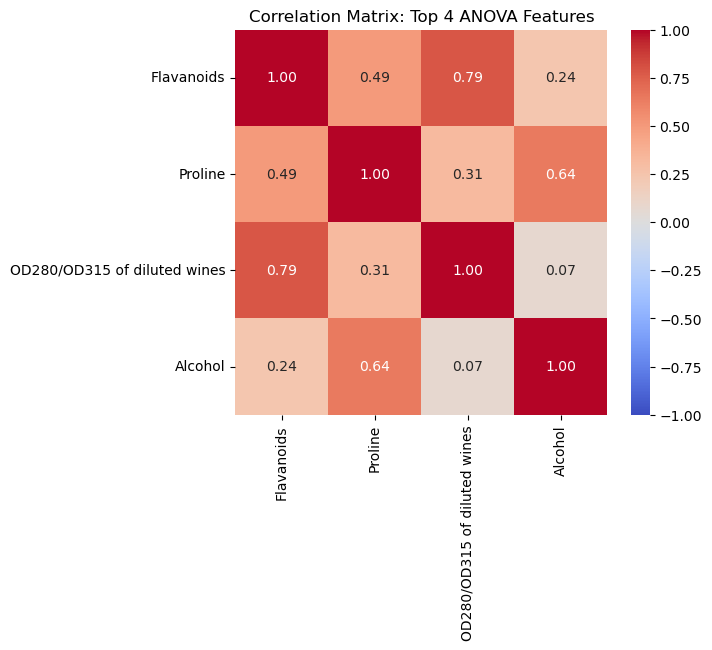

In [27]:
plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f')
plt.title('Correlation Matrix: Top 4 ANOVA Features')
plt.show()

In [28]:
wine_scaled.iloc[:, 1:]

,Alcohol,Malic acid,Ash,Alcalinity of ash,Magnesium,Total phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color intensity,Hue,OD280/OD315 of diluted wines,Proline
0,1.518613,-0.562250,0.232053,-1.169593,1.913905,0.808997,1.034819,-0.659563,1.224884,0.251717,0.362177,1.847920,1.013009
1,0.246290,-0.499413,-0.827996,-2.490847,0.018145,0.568648,0.733629,-0.820719,-0.544721,-0.293321,0.406051,1.113449,0.965242
2,0.196879,0.021231,1.109334,-0.268738,0.088358,0.808997,1.215533,-0.498407,2.135968,0.269020,0.318304,0.788587,1.395148
3,1.691550,-0.346811,0.487926,-0.809251,0.930918,2.491446,1.466525,-0.981875,1.032155,1.186068,-0.427544,1.184071,2.334574
4,0.295700,0.227694,1.840403,0.451946,1.281985,0.808997,0.663351,0.226796,0.401404,-0.319276,0.362177,0.449601,-0.037874
...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,0.876275,2.974543,0.305159,0.301803,-0.332922,-0.985614,-1.424900,1.274310,-0.930179,1.142811,-1.392758,-1.231206,-0.021952
174,0.493343,1.412609,0.414820,1.052516,0.158572,-0.793334,-1.284344,0.549108,-0.316950,0.969783,-1.129518,-1.485445,0.009893
175,0.332758,1.744744,-0.389355,0.151661,1.422412,-1.129824,-1.344582,0.549108,-0.422075,2.224236,-1.612125,-1.485445,0.280575
176,0.209232,0.227694,0.012732,0.151661,1.422412,-1.033684,-1.354622,1.354888,-0.229346,1.834923,-1.568252,-1.400699,0.296498


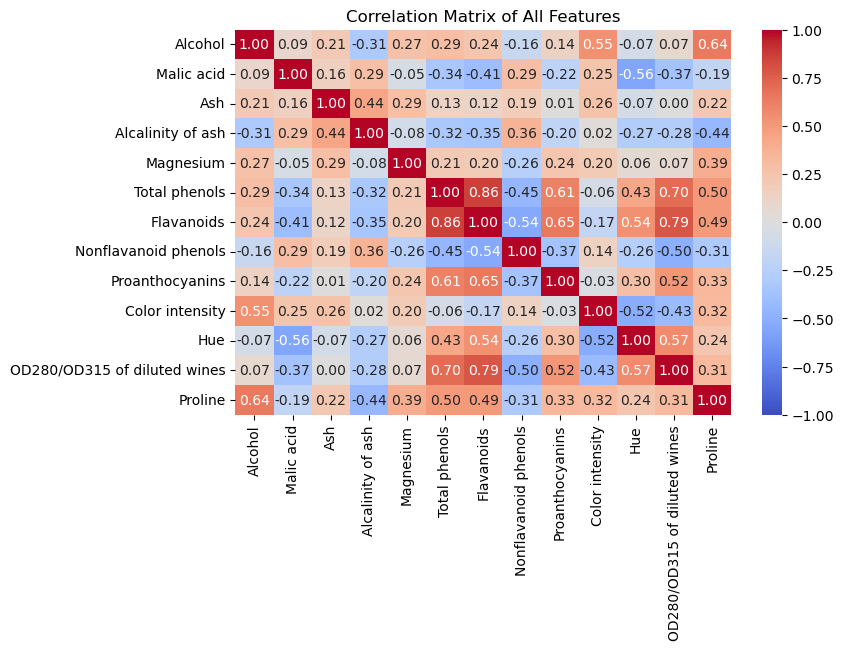

In [29]:
all_features = wine_scaled.iloc[:, 1:]
plt.figure(figsize=(8, 5))
sns.heatmap(all_features.corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f')
plt.title('Correlation Matrix of All Features')
plt.show()

`Flavanoids` vs. `OD280/OD315 of diluted wines` show a **strong positive correlation of ($r = 0.787194$)**. These two features overlap signficantly in the information they provide about wine chemistry. $r = 0.787194$ means nearly 62% of their variance ($r^2 \approx 0.62$) = 0.62$) is shared. Therefore, we can consider **keeping** `Flavanoids`, had the highest F-score, and **dropping** `OD280/OD315 of diluted wines` to prevent redundancy.

In [30]:
top_5_features = ['Flavanoids', 'Proline', 'OD280/OD315 of diluted wines', 'Alcohol', 'Color intensity']
correlation_matrix = wine_scaled[top_5_features].corr()
correlation_matrix

,Flavanoids,Proline,OD280/OD315 of diluted wines,Alcohol,Color intensity
Flavanoids,1.000000,0.494193,0.787194,0.236815,-0.172379
Proline,0.494193,1.000000,0.312761,0.643720,0.316100
OD280/OD315 of diluted wines,0.787194,0.312761,1.000000,0.072343,-0.428815
Alcohol,0.236815,0.643720,0.072343,1.000000,0.546364
Color intensity,-0.172379,0.316100,-0.428815,0.546364,1.000000


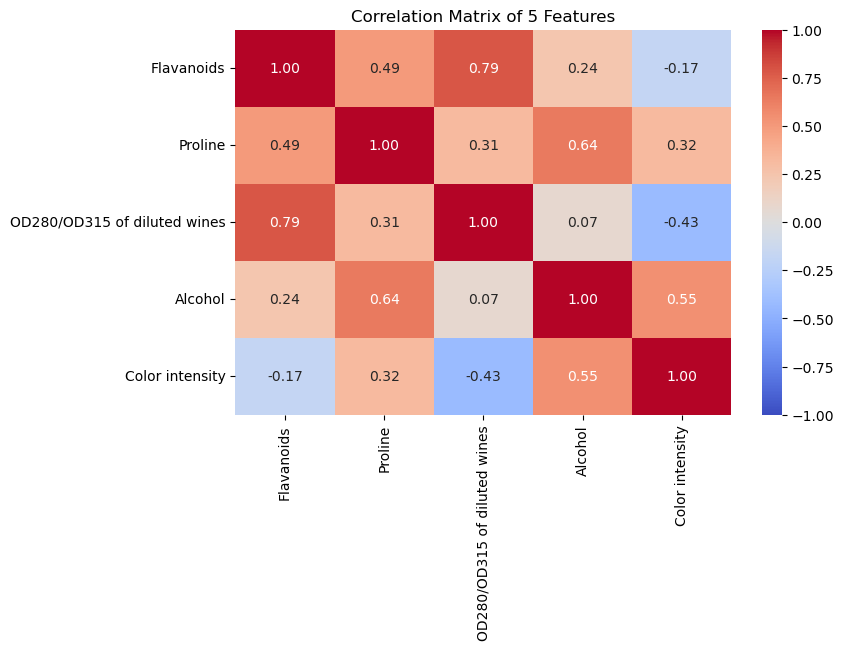

In [31]:
plt.figure(figsize=(8, 5))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f')
plt.title('Correlation Matrix of 5 Features')
plt.show()

## Prepare for Data Training
Split `wine_scaled` into training and testing datasets with testing dataset is 20%

In [32]:
# drop `class` from `wine_scaled`
wine_scaled.drop(columns=['class'], inplace = True)

## Training Models

In [47]:
def randomForest_evaluation(X, y=wine['class'], test_size=0.2, random_state=42):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )

    model = RandomForestClassifier(n_estimators=100, random_state=random_state)
    model.fit(X_train, y_train)

    # Get both predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Calculate accuracies
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    gap = train_acc - test_acc

    print(f"Training accuracy: {train_acc:.4f}")
    print(f"Testing accuracy:  {test_acc:.4f}")
    print(f"Gap: {gap:.4f}")
    print(f"Overfit status: {'✓ Good' if gap < 0.05 else '⚠ Possible overfitting'}")

    # Classification Report
    print(f"Classification Report:\n{classification_report(y_test, y_test_pred)}")

    # Confusion Matrix
    print(f"Confusion Matrix:\n {confusion_matrix(y_test, y_test_pred)}")

    return model

In [34]:
# Create the 4-feature dataset (without OD280/OD315)
df_4_features = wine_scaled[['Flavanoids', 'Proline', 'Alcohol', 'Color intensity']]

# Creat thr 5-feature dataset
df_5_features = wine_scaled[['Flavanoids', 'Proline', 'OD280/OD315 of diluted wines', 'Alcohol', 'Color intensity']]

In [48]:
print("Randome Forest with 4 Features:")
model_4f = randomForest_evaluation(X = df_4_features)

Randome Forest with 4 Features:
Training accuracy: 1.0000
Testing accuracy:  1.0000
Gap: 0.0000
Overfit status: ✓ Good
Classification Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        12
           2       1.00      1.00      1.00        14
           3       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36

Confusion Matrix:
 [[12  0  0]
 [ 0 14  0]
 [ 0  0 10]]


In [49]:
print("Random Forest with 5 Features:")
forest = randomForest_evaluation(X = df_5_features)

Random Forest with 5 Features:
Training accuracy: 1.0000
Testing accuracy:  0.9722
Gap: 0.0278
Overfit status: ✓ Good
Classification Report:
              precision    recall  f1-score   support

           1       0.92      1.00      0.96        12
           2       1.00      0.93      0.96        14
           3       1.00      1.00      1.00        10

    accuracy                           0.97        36
   macro avg       0.97      0.98      0.97        36
weighted avg       0.97      0.97      0.97        36

Confusion Matrix:
 [[12  0  0]
 [ 1 13  0]
 [ 0  0 10]]


From the evaluations of 4-feature-model and 5-feature-model, the 4-feature-model gives us a more accurate results than the other like we have predicted in the Univariate Analysis. However, since this dataset only has 178 observations, the results of both models might vary if we had a larger dataset. 